In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
L = 200          
phi0 = 0.4       # initial lag (fraction of a cycle)
t_end = 600      # total simulation time
 
def rhs(t, v, eps):
    v1, v2 = v
    return [1 + v1**2 + eps*(v2 - v1),
            1 + v2**2 + eps*(v1 - v2)]
 
# events: neuron 1 or neuron 2 reaches +L (going up)
def spike1(t, v, eps): return v[0] - L
def spike2(t, v, eps): return v[1] - L
spike1.terminal = True; spike1.direction = 1
spike2.terminal = True; spike2.direction = 1

In [3]:
def simulate(eps):
    # neuron 1 at reset; neuron 2 a fraction phi0 behind on the orbit v = -cot(pi*theta)
    v = [-L, -1/np.tan(np.pi*(1 - phi0))]
    t = 0.0
    t1, t2 = [], []   # spike times of each neuron
    while t < t_end:
        sol = solve_ivp(rhs, [t, t_end], v, args=(eps,), events=[spike1, spike2],
                        rtol=1e-10, atol=1e-10)
        t = sol.t[-1]
        v = sol.y[:, -1].copy()
        if sol.status == 1:  
            if len(sol.t_events[0]) > 0:
                t1.append(t); v[0] = -L
            if len(sol.t_events[1]) > 0:
                t2.append(t); v[1] = -L
    return np.array(t1), np.array(t2)

In [4]:
def lags(t1, t2):
    #phi_k = (first neuron-2 spike after t1_k - t1_k) / (t1_{k+1} - t1_k)
    
    tk, phik = [], []
    for k in range(len(t1) - 1):
        after = t2[t2 > t1[k]]
        if len(after) == 0:
            break
        tk.append(t1[k])
        phik.append((after[0] - t1[k]) / (t1[k+1] - t1[k]))
    return np.array(tk), np.array(phik)
 
def prediction(t, eps):
    return np.arctan(np.tan(np.pi*phi0)*np.exp(-2*eps*t)) / np.pi

 eps    fitted rate   2*eps   ratio
0.005   0.00976      0.010   0.9763
0.020   0.03874      0.040   0.9685
0.050   0.09495      0.100   0.9495


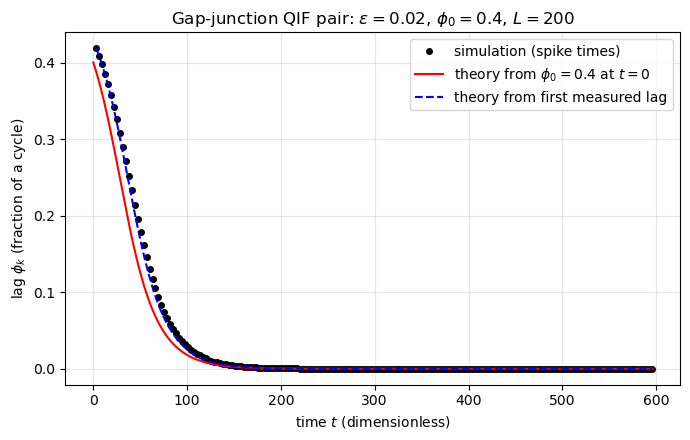

In [5]:
eps = 0.02
tk, phik = lags(*simulate(eps))
tt = np.linspace(0, tk.max(), 500)
 
plt.figure(figsize=(7, 4.5))
plt.plot(tk, phik, 'ko', ms=4, label='simulation (spike times)')
plt.plot(tt, prediction(tt, eps), 'r-', label=r'theory from $\phi_0=0.4$ at $t=0$')

tt2 = np.linspace(tk[0], tk.max(), 500)
th2 = np.arctan(np.tan(np.pi*phik[0])*np.exp(-2*eps*(tt2 - tk[0]))) / np.pi
plt.plot(tt2, th2, 'b--', label='theory from first measured lag')
plt.xlabel('time $t$ (dimensionless)')
plt.ylabel(r'lag $\phi_k$ (fraction of a cycle)')
plt.title(r'Gap-junction QIF pair: $\varepsilon=0.02$, $\phi_0=0.4$, $L=200$')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('hw3_problem4c.png', dpi=200)
 
#fit decay rate of tan(pi*phi_k)
print(" eps    fitted rate   2*eps   ratio")
for eps in [0.005, 0.02, 0.05]:
    tk, phik = lags(*simulate(eps))
    keep = (phik > 0.005) & (phik < 0.5)        # skip wrapped points
    slope = np.polyfit(tk[keep], np.log(np.tan(np.pi*phik[keep])), 1)[0]
    print(f"{eps:5.3f}   {-slope:.5f}      {2*eps:.3f}   {-slope/(2*eps):.4f}")
 